# DANIEL PORRAS MORALES - 12/01/2026

# **CRITERIOS DE CALIFICACIÓN**

RA.03:

*   Preguntas 1 a 9 valen 1 punto, excepto la 7 que vale 2 puntos.
*   Las preguntas 10, 11, 13 y 15 valen 2.5 puntos.

Esto suma 20 puntos, que constituyen el 85% de la calificación del RA. El 15% restante es el proyecto.



RA.06:

*   Pregunta 12: 30% del RA
*   Pregunta 14: 30% del RA

Un 25% restante es para aprendizaje no supervisado y el 15% que queda del proyecto.



# **DATASET**


Este dataset cuenta con más de 25000 partidos y 10000 jugadores, desde 2008 hasta 2016.

La base de datos se estructura en 7 tablas:

*   Country: Contiene los 11 paises de los que provienen los datos, Bélgica, Inglaterra, Francia, Alemania, Italia, Holanda, Polonia, Portugal, Escocia, España y Suiza.
*   League: Mapea los 11 paises a sus respectivas liga.
*   Match: Esta tabla contiene todos los partidos con la información de eventos como por ejemplo goles, faltas o porcentaje de posesión. Además de los 22 jugadores que jugaron el partido de inicio, la liga a la que pertenece y los goles de cada equipo.
*   Player: Incluye los nombres de los jugadores, su peso y altura, vinculándolos con un id único para acceder a sus atributos.
*   Player_Attributes: 39 columnas con diferentes características de los jugadores como definición de cara a puerta, pie favorito o reflejos de portero, además de la fecha de actualización del atributo y los identificadores para cruzar con la tabla de jugadores.
*   Team: Identificadores únicos y nombres de cada equipo.
*   Team_Attributes: Similar a la tabla de Player_Attributes pero con atributos como la capacidad de creación de juego o de crear una ocasión de peligro.


https://www.kaggle.com/datasets/hugomathien/soccer/data

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sqlite3

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

conn = sqlite3.connect('/content/drive/MyDrive/Datasets/SAA/database.sqlite')
conn

Mounted at /content/drive


In [31]:
tables = pd.read_sql("""SELECT *
                        FROM sqlite_master
                        WHERE type='table';""", conn)
tables

,type,name,tbl_name,rootpage,sql
0,table,sqlite_sequence,sqlite_sequence,4,"CREATE TABLE sqlite_sequence(name,seq)"
1,table,Player_Attributes,Player_Attributes,11,"CREATE TABLE ""Player_Attributes"" (\n\t`id`\tIN..."
2,table,Player,Player,14,CREATE TABLE `Player` (\n\t`id`\tINTEGER PRIMA...
3,table,Match,Match,18,CREATE TABLE `Match` (\n\t`id`\tINTEGER PRIMAR...
4,table,League,League,24,CREATE TABLE `League` (\n\t`id`\tINTEGER PRIMA...
5,table,Country,Country,26,CREATE TABLE `Country` (\n\t`id`\tINTEGER PRIM...
6,table,Team,Team,29,"CREATE TABLE ""Team"" (\n\t`id`\tINTEGER PRIMARY..."
7,table,Team_Attributes,Team_Attributes,2,CREATE TABLE `Team_Attributes` (\n\t`id`\tINTE...


In [32]:
# Load each table into a pandas DataFrame

player_attributes = pd.read_sql("SELECT * FROM Player_Attributes", conn)
player = pd.read_sql("SELECT * FROM Player", conn)
match = pd.read_sql("SELECT * FROM Match", conn)
league = pd.read_sql("SELECT * FROM League", conn)
country = pd.read_sql("SELECT * FROM Country", conn)
team = pd.read_sql("SELECT * FROM Team", conn)
team_attributes = pd.read_sql("SELECT * FROM Team_Attributes", conn)

# **EXPLORACIÓN DE DATOS**

In [33]:
# Cómo son muchos registros, vamos a reducirlo para que vaya más rápido
player_attributes = player_attributes.sample(frac=0.5)

## **PREGUNTA 1: MUESTRA EL NÚMERO DE FILAS Y COLUMNAS DE player_attributes**

Tenemos un total de 91989 Filas y 42 Columnas en 'player_attributes'

In [35]:
player_attributes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91989 entries, 148709 to 149784
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   91989 non-null  int64  
 1   player_fifa_api_id   91989 non-null  int64  
 2   player_api_id        91989 non-null  int64  
 3   date                 91989 non-null  object 
 4   overall_rating       91576 non-null  float64
 5   potential            91576 non-null  float64
 6   preferred_foot       91576 non-null  object 
 7   attacking_work_rate  90372 non-null  object 
 8   defensive_work_rate  91576 non-null  object 
 9   crossing             91576 non-null  float64
 10  finishing            91576 non-null  float64
 11  heading_accuracy     91576 non-null  float64
 12  short_passing        91576 non-null  float64
 13  volleys              90612 non-null  float64
 14  dribbling            91576 non-null  float64
 15  curve                90612 non-null

## **PREGUNTA 2: ¿CÓMO SE PUEDE SABER CUÁNTOS NULOS HAY EN player_attributes?**

In [36]:
player_attributes.isnull().sum()

,0
id,0
player_fifa_api_id,0
player_api_id,0
date,0
overall_rating,413
potential,413
preferred_foot,413
attacking_work_rate,1617
defensive_work_rate,413
crossing,413


In [65]:
player_attributes.isnull().mean() * 100

,0
overall_rating,0.0
potential,0.0
preferred_foot,0.0
crossing,0.0
finishing,0.0
heading_accuracy,0.0
short_passing,0.0
volleys,0.0
dribbling,0.0
curve,0.0


In [66]:
porcentajes = (player_attributes.isnull().sum()/len(player_attributes))*100
porcentajes

,0
overall_rating,0.0
potential,0.0
preferred_foot,0.0
crossing,0.0
finishing,0.0
heading_accuracy,0.0
short_passing,0.0
volleys,0.0
dribbling,0.0
curve,0.0


## **PREGUNTA 3: ¿QUÉ VALORES CONTIENEN LAS VARIABLES preferred_food, attacking_work_rate y defensive_work_rate?**

In [37]:
player_attributes['preferred_foot'].value_counts()

,count
preferred_foot,
right,69300
left,22276


In [38]:
player_attributes['attacking_work_rate'].value_counts()

,count
attacking_work_rate,
medium,62500
high,21369
low,4322
None,1863
norm,171
le,51
y,51
stoc,45


In [39]:
player_attributes['defensive_work_rate'].value_counts()

,count
defensive_work_rate,
medium,65394
high,13460
low,9253
_0,1204
o,798
1,217
ormal,171
2,170
5,129


# **PREPARACIÓN DE DATOS**

**Nos vamos a centrar en la tabla player_attributes, y la variable objetivo es overall_rating**

## PREGUNTA 4: SI LA VARIABLE OBJETIVO ES overall_rating, ¿ES CLASIFICACIÓN O REGRESIÓN? JUSTIFICA LA RESPUESTA

La variable 'overall_rating' es una variable númerica luego es de tipo regresión ya que se trata de predecir un valor númerico

Ej: 88

Sería clasificación para determinar si es un jugador elite o no, por ejemplo

In [41]:
player_attributes['overall_rating'].value_counts()

,count
overall_rating,
68.0,5209
69.0,5172
67.0,5150
70.0,4984
66.0,4970
72.0,4880
71.0,4703
65.0,4664
64.0,4515


## PREGUNTA 5: ELIMINA LAS VARIABLES id, player_fifa_api_id, player_api_id y date

In [42]:
player_attributes.drop(labels=['id','player_fifa_api_id','player_api_id','date'], axis=1, inplace=True)

In [43]:
player_attributes.head()

,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,finishing,heading_accuracy,short_passing,volleys,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
148709,79.0,88.0,right,high,low,80.0,65.0,49.0,76.0,80.0,...,72.0,70.0,21.0,21.0,17.0,7.0,21.0,71.0,21.0,21.0
41509,60.0,69.0,right,None,o,49.0,46.0,61.0,54.0,54.0,...,51.0,54.0,62.0,64.0,59.0,11.0,24.0,52.0,24.0,24.0
98027,65.0,69.0,right,medium,medium,17.0,12.0,16.0,29.0,11.0,...,35.0,25.0,18.0,15.0,12.0,64.0,66.0,65.0,66.0,64.0
29514,73.0,73.0,right,low,high,52.0,42.0,74.0,75.0,39.0,...,60.0,49.0,68.0,77.0,72.0,9.0,12.0,15.0,12.0,10.0
31004,77.0,77.0,right,medium,low,72.0,78.0,87.0,73.0,79.0,...,68.0,70.0,36.0,45.0,21.0,16.0,15.0,8.0,15.0,13.0


## **PREGUNTA 6: ¿POR QUÉ HEMOS ELIMINADO ESTAS VARIABLES?**

Al ser variables unicas para cada jugador, no nos aportan nada en nuestro modelo, lo cuál eliminandolas reducimos la cantidad de recursos que tenemos que destinar para entrenar nuestro modelo.

## Nulos

## **PREGUNTA 7: SUSTITUYE LOS NULOS DE LAS VARIABLES NUMÉRICAS POR LA MEDIA Y LOS DE LAS VARIABLES CATEGÓRICAS POR LA MODA**

In [45]:
cols_numericas = player_attributes.select_dtypes(include=['number']).columns
cols_categoricas = player_attributes.select_dtypes(include=['object']).columns

player_attributes[cols_numericas] = player_attributes[cols_numericas].fillna(player_attributes[cols_numericas].mean())


for col in cols_categoricas:
    if not player_attributes[col].mode().empty:
        moda = player_attributes[col].mode()[0]
        player_attributes[col] = player_attributes[col].fillna(moda)

player_attributes.isnull().sum()

,0
overall_rating,0
potential,0
preferred_foot,0
attacking_work_rate,0
defensive_work_rate,0
crossing,0
finishing,0
heading_accuracy,0
short_passing,0
volleys,0


## Variables categóricas

Codificamos preferred_foot

In [46]:
player_attributes['preferred_foot']  = player_attributes['preferred_foot'].map({'right':1,'left':2}).astype('int64')

attacking_work_rate y defensive_work_rate contienen un rango de valores muy parecido por lo que pasamos a unificar los datos

In [47]:
player_attributes['attacking_work_rate'].replace({'le':'lean','norm':'normal','stoc':'stocky','y':'yes'}, inplace=True)

/tmp/ipython-input-3712950697.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  player_attributes['attacking_work_rate'].replace({'le':'lean','norm':'normal','stoc':'stocky','y':'yes'}, inplace=True)


In [48]:
player_attributes['defensive_work_rate'].replace({'ean':'lean','ormal':'normal','tocky':'stocky','es':'yes','o':'None','_0':'medium'}, inplace=True)
# Los valores numéricos los sustituimos por 'None'
player_attributes.loc[ player_attributes['defensive_work_rate'].isin(list('0123456789')) , 'defensive_work_rate' ] = 'None'

/tmp/ipython-input-3648946072.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  player_attributes['defensive_work_rate'].replace({'ean':'lean','ormal':'normal','tocky':'stocky','es':'yes','o':'None','_0':'medium'}, inplace=True)


In [49]:
player_attributes['attacking_work_rate'].value_counts()

,count
attacking_work_rate,
medium,64117
high,21369
low,4322
None,1863
normal,171
lean,51
yes,51
stocky,45


In [50]:
player_attributes['defensive_work_rate'].value_counts()

,count
defensive_work_rate,
medium,67011
high,13460
low,9253
None,1947
normal,171
lean,51
yes,51
stocky,45


## **PREGUNTA 8: CREA DUMMIES PARA attacking_work_rate y defensive_work_rate Y ELIMÍNALAS**

In [51]:
player_attributes = pd.get_dummies(player_attributes,
                    columns=['attacking_work_rate', 'defensive_work_rate'],
                    dtype=int)

In [52]:
player_attributes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91989 entries, 148709 to 149784
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   overall_rating              91989 non-null  float64
 1   potential                   91989 non-null  float64
 2   preferred_foot              91989 non-null  int64  
 3   crossing                    91989 non-null  float64
 4   finishing                   91989 non-null  float64
 5   heading_accuracy            91989 non-null  float64
 6   short_passing               91989 non-null  float64
 7   volleys                     91989 non-null  float64
 8   dribbling                   91989 non-null  float64
 9   curve                       91989 non-null  float64
 10  free_kick_accuracy          91989 non-null  float64
 11  long_passing                91989 non-null  float64
 12  ball_control                91989 non-null  float64
 13  acceleration                91

## PREGUNTA 9: ¿HAY ALGUNA VARIABLE CON OUTLIERS? EXPLÍCALO

--- Variables con mayor cantidad de Outliers ---
preferred_foot                22276
attacking_work_rate_high      21369
gk_kicking                    20060
defensive_work_rate_high      13460
defensive_work_rate_low        9253
ball_control                   8013
gk_diving                      7478
gk_reflexes                    7458
gk_positioning                 7447
gk_handling                    7446
short_passing                  6561
dribbling                      4652
shot_power                     4616
heading_accuracy               4559
attacking_work_rate_low        4322
stamina                        4287
acceleration                   3227
sprint_speed                   3034
jumping                        2129
defensive_work_rate_None       1947
balance                        1913
attacking_work_rate_None       1863
reactions                      1814
strength                       1654
long_passing                   1443
agility                        1308
overall_rating 

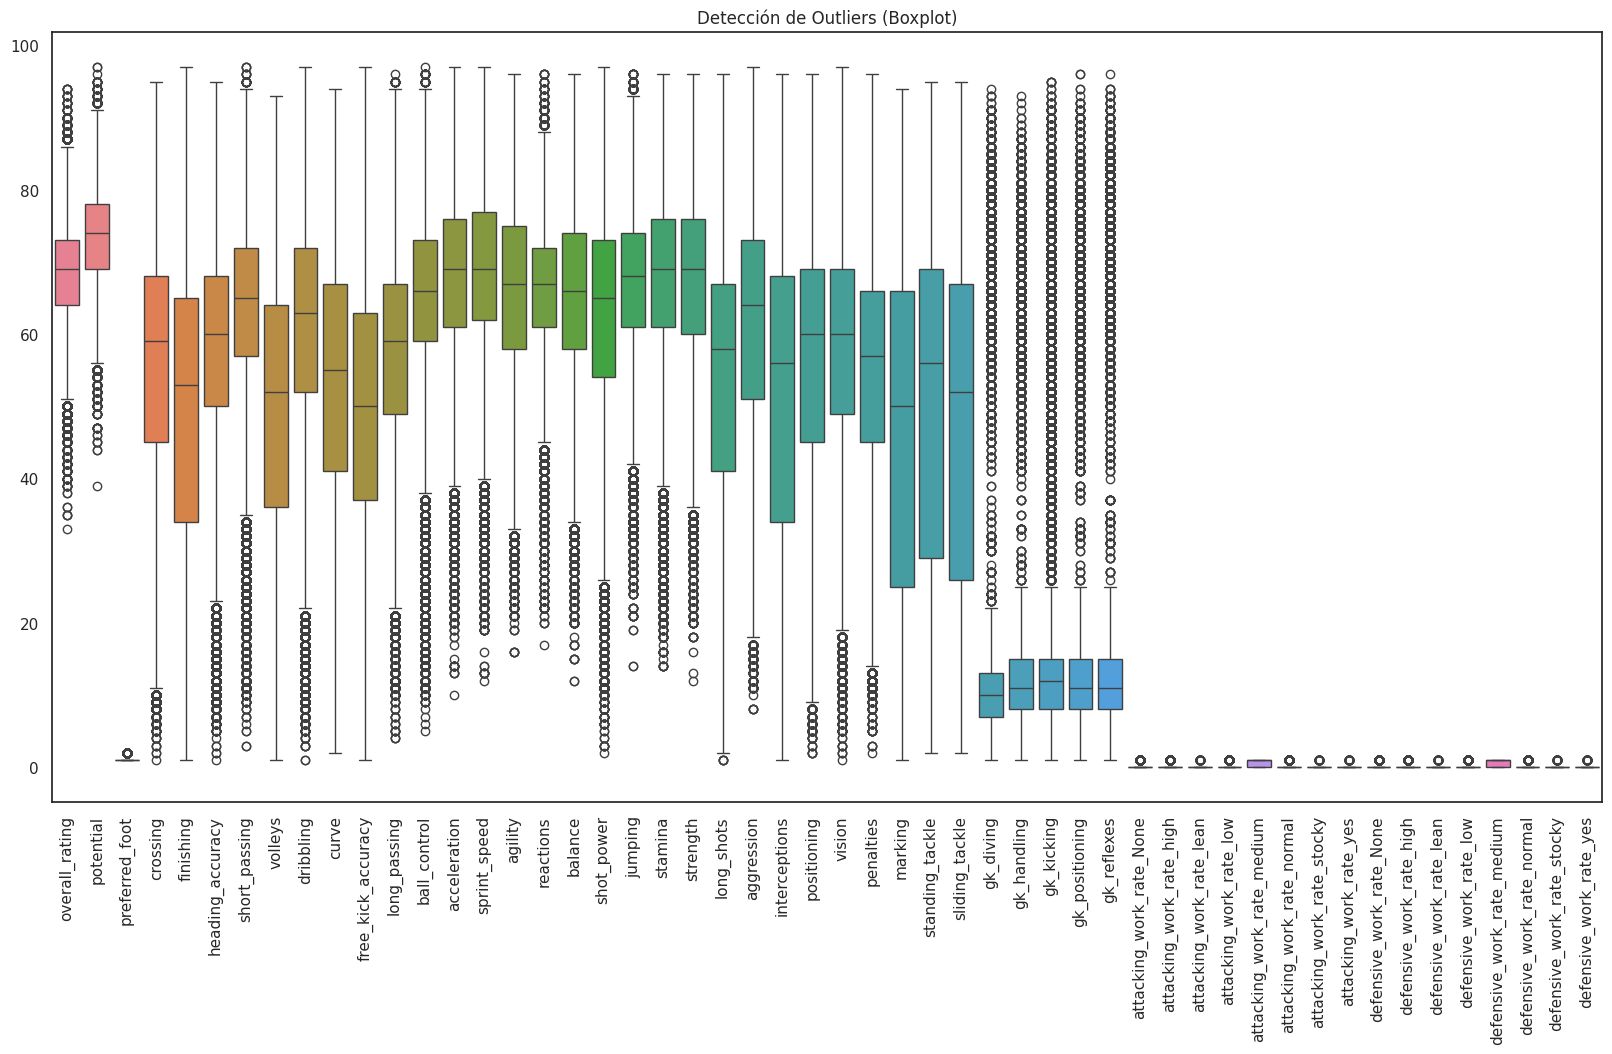

In [53]:
cols_numericas = player_attributes.select_dtypes(include=['number'])

Q1 = cols_numericas.quantile(0.25)
Q3 = cols_numericas.quantile(0.75)
IQR = Q3 - Q1

# Identificar outliers (True si es outlier, False si no)
outliers_mask = (cols_numericas < (Q1 - 1.5 * IQR)) | (cols_numericas > (Q3 + 1.5 * IQR))

# Contar cuántos outliers tiene cada variable
conteo_outliers = outliers_mask.sum().sort_values(ascending=False)

print("--- Variables con mayor cantidad de Outliers ---")
print(conteo_outliers[conteo_outliers > 0])

# 5. Visualización Gráfica (Boxplot)
# Ajustamos el tamaño para que se vean bien todas las variables
plt.figure(figsize=(20, 10))
# Rotamos las etiquetas del eje X para que se lean los nombres
sns.boxplot(data=cols_numericas)
plt.xticks(rotation=90)
plt.title("Detección de Outliers (Boxplot)")
plt.show()

Nos encontramos con muchos outliners debido a ciertos aspectos:

Un futbolista puede jugar en muchas posiciones y dependendiedo de la posición que ese futbolista juegue, tendrá unas carácteristicas muy potenciadas y otras de las que carezca, un defensa no tendrá el mismo regate que un delantero y un delantero no tendrá la misma defensa.

También puede que haya jugadores en ligas inferiores donde estos jugadores tengan menores carácteristicas que los elite mundiales.

# **REDUCCIÓN DIMENSIONALIDAD**

## **Feature importance**

In [54]:
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor

# Vamos a coger como variable objetivo 'overall_rating'
X = player_attributes.drop(labels=['overall_rating'], axis=1)
y = player_attributes['overall_rating']
model = ExtraTreesRegressor()
model.fit(X,y)

ExtraTreesRegressor()

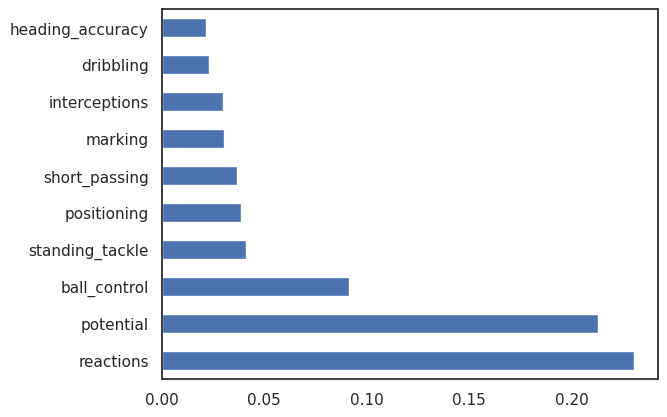

In [55]:
# Mostramos las 10 características más importantes
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

## **Correlation (Pearson)**

## PREGUNTA 10: IMPRIME LA CORRELACIÓN EXISTENTE ENTRE TODAS LAS VARIABLES Y LA VARIABLE OBJETIVO, ORDENADAS DE MAYOR A MENOR Y COMPRUEBA SI SE CORRESPONDE CON LO OBTENIDO EN FEATURE IMPORTANCE

In [56]:
# Correlación de todas las variables con la variable objetivo
correlations = player_attributes.corr()['overall_rating']

# Quitamos la autocorrelación (overall_rating consigo misma)
correlations = correlations.drop('overall_rating')

# Ordenamos de mayor a menor
correlations_sorted = correlations.sort_values(ascending=False)

# Mostramos las 10 variables más correlacionadas
print(correlations_sorted.head(10))

reactions        0.768673
potential        0.766011
short_passing    0.458317
ball_control     0.442004
long_passing     0.433546
shot_power       0.426158
vision           0.426039
penalties        0.390456
long_shots       0.389567
positioning      0.368376
Name: overall_rating, dtype: float64


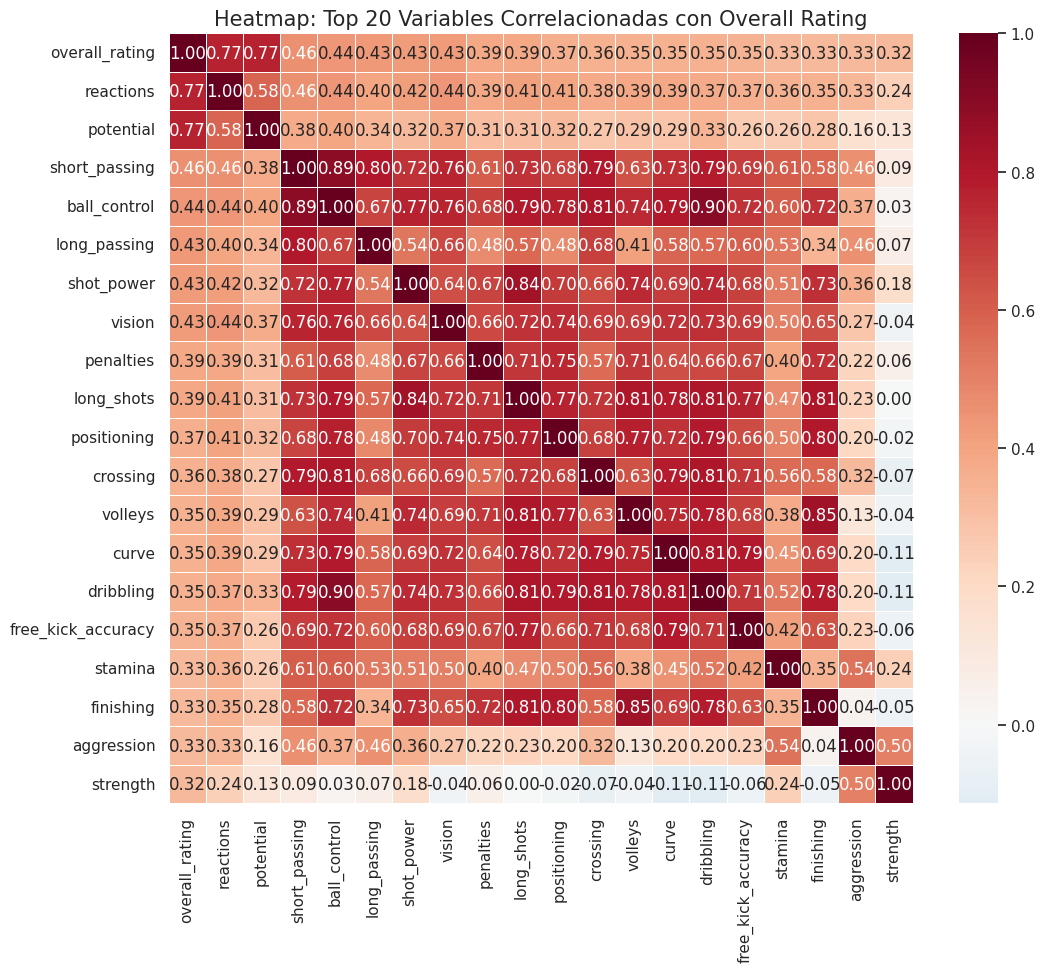

In [57]:
df_numeric = player_attributes.select_dtypes(include=['number'])

corr_matrix = df_numeric.corr()

# Seleccionar las 20 variables con mayor correlación absoluta con la variable objetivo
top_features = corr_matrix['overall_rating'].abs().sort_values(ascending=False).head(20).index
filtered_corr = df_numeric[top_features].corr()

plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

heatmap = sns.heatmap(
    filtered_corr,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    linewidths=0.5,
    center=0               # El blanco representa correlación cero
)

plt.title("Heatmap: Top 20 Variables Correlacionadas con Overall Rating", fontsize=15)
plt.show()

En general, si están las variables en lo obtenido según feature importance. Las características más correlacionadas positivamente con overall_rating suelen aparecer entre las más relevantes del modelo. Sin embargo, el orden puede no coincidir, pero normalmente las variables más correlacionadas son relevantes en el modelo

## **PCA**

## PREGUNTA 11: APLICA PCA PARA REDUCIR DIMENSIONALIDAD. ¿CON CUANTAS VARIABLES TE QUEDARÍAS?

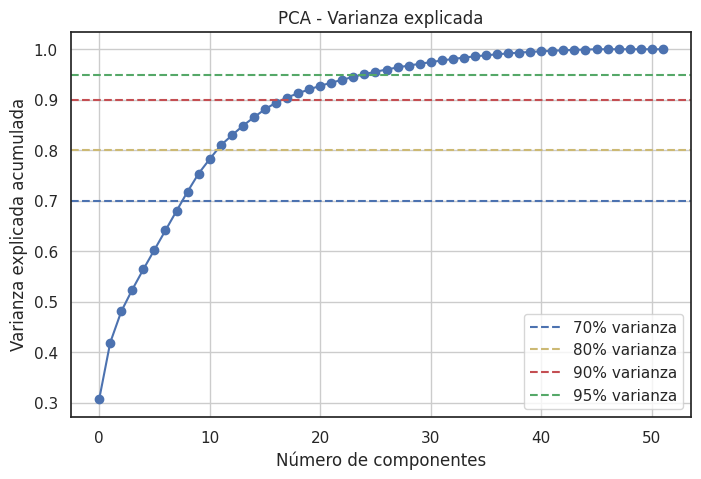


 Numero de componentes según % de Varianza
Componentes para 70% de varianza: 9
Componentes para 80% de varianza: 12
Componentes para 90% de varianza: 18
Componentes para 95% de varianza: 25


In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = player_attributes.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicamos PCA (sin limitar componentes)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# 6. Gráfico de varianza acumulada
plt.figure(figsize=(8,5))
plt.plot(varianza_acumulada, marker='o')
plt.axhline(y=0.70, color='b', linestyle='--', label='70% varianza')
plt.axhline(y=0.80, color='y', linestyle='--', label='80% varianza')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% varianza')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% varianza')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - Varianza explicada")
plt.legend()
plt.grid(True)
plt.show()

# 7. Número de componentes necesarios
n_70 = np.argmax(varianza_acumulada >= 0.70) + 1
n_80 = np.argmax(varianza_acumulada >= 0.80) + 1
n_90 = np.argmax(varianza_acumulada >= 0.90) + 1
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1

print("\n Numero de componentes según % de Varianza")
print(f"Componentes para 70% de varianza: {n_70}")
print(f"Componentes para 80% de varianza: {n_80}")
print(f"Componentes para 90% de varianza: {n_90}")
print(f"Componentes para 95% de varianza: {n_95}")

Tras aplicar PCA sin limitar componentes, me quedo entre 12 y 18 componentes ya que explican aproximadamente entrono a un 80% / 90% de la varianza total

# **APRENDIZAJE SUPERVISADO**

## **REGRESIÓN LINEAL**

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

X = player_attributes.drop(labels=['overall_rating'], axis=1)
y = player_attributes['overall_rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7)

# Pipeline se usa para encadenar múltiples estimadores en uno
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=12)),
    ('logistic', LinearRegression())
])

pipe.fit(X_train, y_train).score(X_test, y_test)

0.7042812024999043

## PREGUNTA 12: ¿QUÉ MÉTRICAS APLICARÍAS? EXPLICA AL MENOS 2

En un problema de regresión aplicaría métricas estas métricas:

MAE (Mean Absolute Error):
Es la métrica más fácil de interpretar. Indica, de media, cuántos puntos de diferencia hay entre el overall_rating real y el predicho por el modelo.
Por ejemplo, un MAE de 2 significa que el modelo se equivoca, en promedio, en 2 puntos de rating.

RMSE (Root Mean Squared Error):
Similar al MAE, pero penaliza más los errores grandes. Es útil para detectar si el modelo falla mucho al predecir jugadores con valoraciones muy altas o muy bajas.

R² (Coeficiente de Determinación):
Mide qué porcentaje de la variabilidad del overall_rating es explicado por el modelo.
Un R² = 0.75 indicaría que el modelo explica el 75% de las variaciones en la valoración de los jugadores.

Ambas permiten evaluar precisión y calidad del ajuste del modelo.

## **SVM**

## PREGUNTA 13: APLICA SVM PARA INFERIR overall_rating

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

X = player_attributes.drop(labels=['overall_rating'], axis=1)
y = player_attributes['overall_rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42
)

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=12)),
    ('svr', SVR(kernel='rbf'))
])

# Entrenamiento
pipe_svm.fit(X_train, y_train)

# Evaluación (R²)
score = pipe_svm.score(X_test, y_test)
print(f"R² en test: {score:.3f}")


R² en test: 0.924


## PREGUNTA 14: USA GridSearchCV PARA ESTIMAR EL MEJOR PARÁMETRO DE KERNEL

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

X = player_attributes.drop(labels=['overall_rating'], axis=1)
y = player_attributes['overall_rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42
)

# Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=12)),
    ('svr', SVR())
])

# SOLO kernels (muy rápido)
param_grid = {
    'svr__kernel': ['linear', 'rbf', 'poly']
}

# GridSearch
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Entrenamiento
grid.fit(X_train, y_train)

# Resultados
print("Mejor kernel:", grid.best_params_['svr__kernel'])
print("Mejor R² (CV):", grid.best_score_)

# Evaluación final
print("R² en test:", grid.best_estimator_.score(X_test, y_test))

El mejor kernel para este problema es rbf, porque la relación entre los atributos técnicos de un jugador y su valoración general (overall_rating) no es lineal

In [ ]:
df

,kernel,Accuracy
0,linear,0.698344
1,poly,0.517166
2,rbf,0.916428


## **DECISION TREES**

## PREGUNTA 15: APLICA DECISION TREES PARA INFERIR overall_rating

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Variables
X = player_attributes.drop(labels=['overall_rating'], axis=1)
y = player_attributes['overall_rating']

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42
)

# Modelo Decision Tree para regresión
tree = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

# Entrenamiento
tree.fit(X_train, y_train)

# Predicciones
y_pred = tree.predict(X_test)

# Evaluación
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R²: 0.8957561083467906
MAE: 1.5900248480510182
